# Loan Approval Prediction — Decision Tree + SVM

**Goal:** Given an applicant's profile (income, credit history, dependents, property area, etc.), predict whether their loan will be **Approved (Y)** or **Rejected (N)**.

**Why decision trees?** Banks need *explainable* decisions. A tree gives a human-readable rule path: "If credit history = 1 AND total income > X AND loan amount < Y → Approve". We compare it against an SVM (a strong but less interpretable baseline).

**Pipeline overview:**
1. Load and explore the dataset
2. EDA — distributions, missing values, target relationships
3. Data cleaning + feature engineering (shared with the Streamlit app via `app/features.py`)
4. Preprocessing pipeline (one-hot + scaling)
5. Train Decision Tree with `GridSearchCV`
6. Train SVM with `GridSearchCV`
7. Compare metrics, ROC curves
8. Persist both fitted pipelines for the Streamlit app

In [1]:
import sys, os
# Make the shared feature module importable.
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)

from app.features import clean_and_engineer, CATEGORICAL_FEATURES, NUMERIC_FEATURES

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)
print('Imports OK')

Imports OK


## 1. Load the data

The dataset (Analytics Vidhya / Kaggle `ninzaami/loan-predication`) contains 614 historical loan applications labeled with the bank's decision.

In [2]:
DATA_PATH = '../data/raw/train.csv'
raw = pd.read_csv(DATA_PATH)
print('Shape:', raw.shape)
raw.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB


In [4]:
raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loan_ID,614,614,LP001002,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,601,2,Male,489,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Married,611,2,Yes,398,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,599,4,0,345,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,614,2,Graduate,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Self_Employed,582,2,No,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ApplicantIncome,614.0,NaN,NaN,NaN,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.0,81000.0
CoapplicantIncome,614.0,NaN,NaN,NaN,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,NaN,NaN,NaN,146.412162,85.587325,9.0,100.0,128.0,168.0,700.0
Loan_Amount_Term,600.0,NaN,NaN,NaN,342.0,65.12041,12.0,360.0,360.0,360.0,480.0


**Observations from `.info()` / `.describe()`:**
- 614 rows, 13 columns (12 features + target `Loan_Status`).
- Several columns have missing values: `Gender`, `Married`, `Dependents`, `Self_Employed`, `LoanAmount`, `Loan_Amount_Term`, `Credit_History`.
- `Dependents` contains the string `"3+"` — needs cleaning.
- `Credit_History` is float (0.0 / 1.0) but is conceptually categorical.
- Numeric ranges (`ApplicantIncome`, `LoanAmount`) span several orders of magnitude → log transform candidates.

## 2. Exploratory Data Analysis

### 2.1 Target distribution

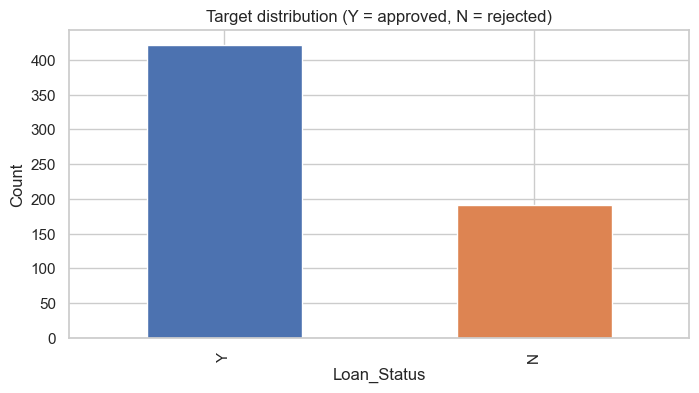

Loan_Status
Y    0.687
N    0.313
Name: proportion, dtype: float64


In [5]:
ax = raw['Loan_Status'].value_counts().plot(kind='bar', color=['#4c72b0', '#dd8452'])
ax.set_title('Target distribution (Y = approved, N = rejected)')
ax.set_ylabel('Count')
plt.show()
print(raw['Loan_Status'].value_counts(normalize=True).round(3))

About **69% approved / 31% rejected** — a moderate class imbalance. We will use a **stratified split** and report **F1 / ROC-AUC** in addition to accuracy.

### 2.2 Missing values

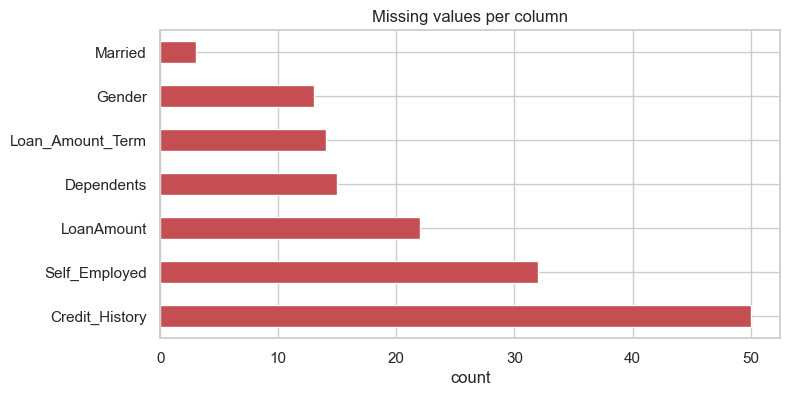

Credit_History      50
Self_Employed       32
LoanAmount          22
Dependents          15
Loan_Amount_Term    14
Gender              13
Married              3
dtype: int64

In [6]:
missing = raw.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing.plot(kind='barh', color='#c44e52')
plt.title('Missing values per column')
plt.xlabel('count')
plt.show()
missing

**Strategy** (implemented in `app/features.clean_and_engineer`):
- Categoricals (`Gender`, `Married`, `Dependents`, `Self_Employed`, `Credit_History`) → mode.
- Numerics (`LoanAmount`, `Loan_Amount_Term`) → median.

We compute these statistics on the training set only and reuse them at inference time so the Streamlit app never "peeks" at unseen data.

### 2.3 Numeric feature distributions

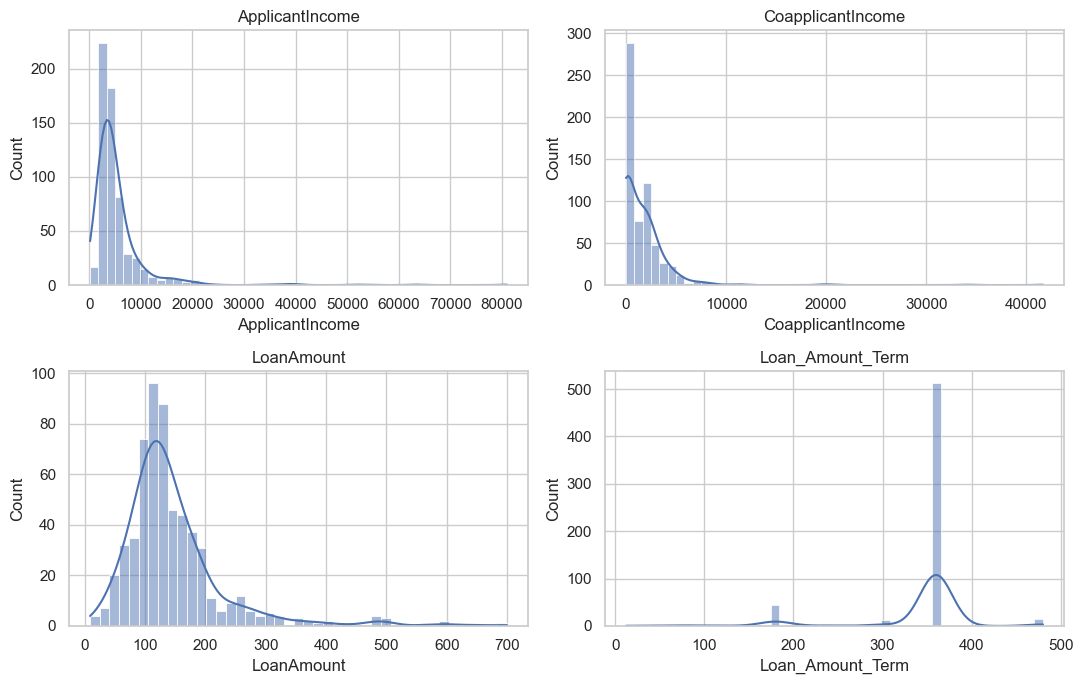

In [7]:
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, c in zip(axes.flat, num_cols):
    sns.histplot(raw[c].dropna(), kde=True, ax=ax, color='#4c72b0')
    ax.set_title(c)
plt.tight_layout(); plt.show()

**`ApplicantIncome` and `LoanAmount` are right-skewed** — a `log1p` transform will compress the long tail and help linear models like SVM.

### 2.4 Categorical features vs target

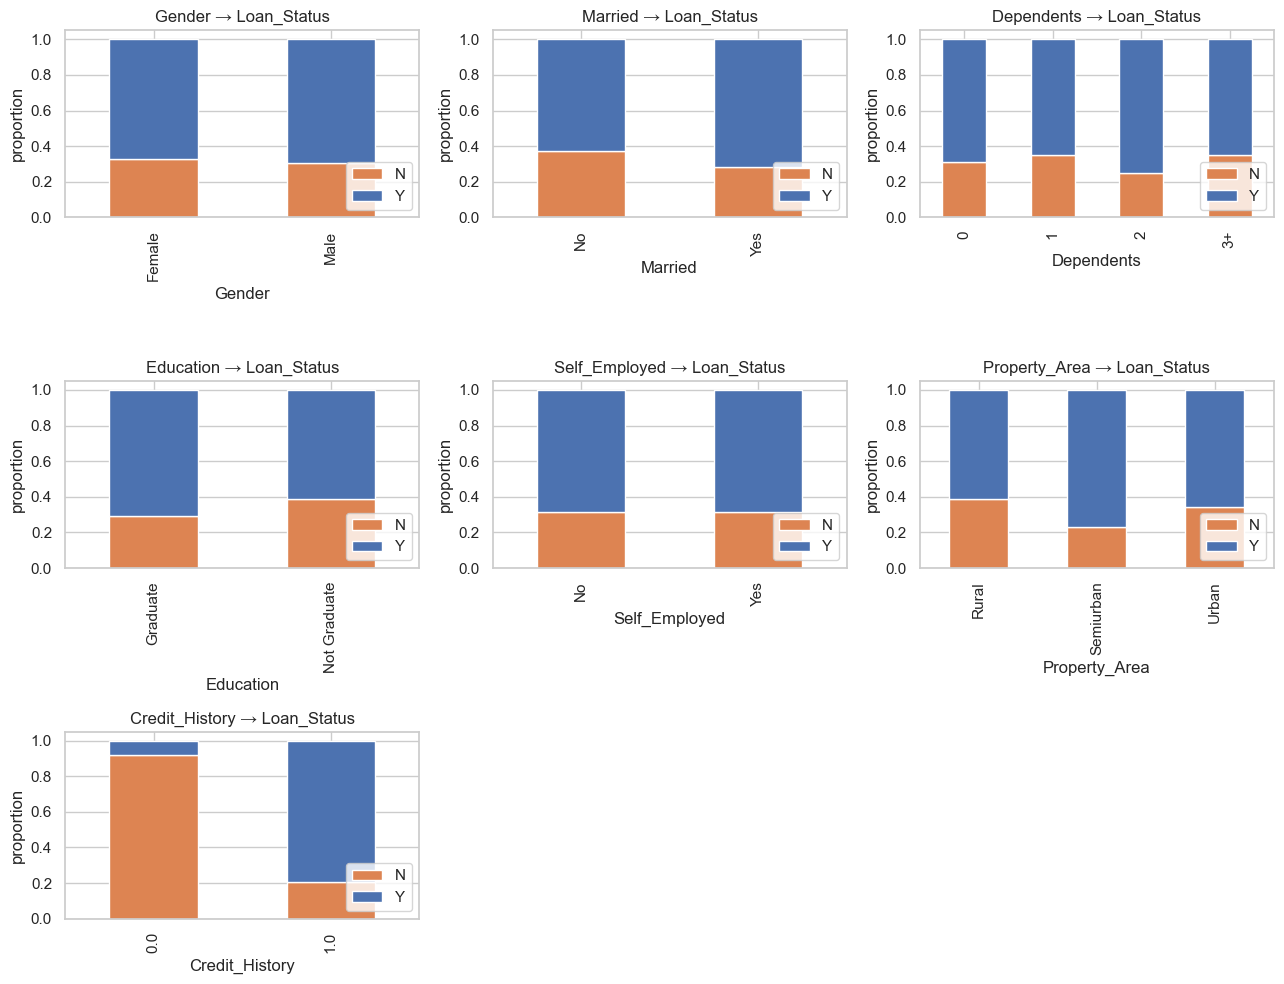

In [8]:
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
            'Property_Area', 'Credit_History']
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ax, c in zip(axes.flat, cat_cols):
    pd.crosstab(raw[c], raw['Loan_Status'], normalize='index').plot(
        kind='bar', stacked=True, ax=ax, color=['#dd8452', '#4c72b0'])
    ax.set_title(f'{c} → Loan_Status')
    ax.set_ylabel('proportion')
    ax.legend(title='', loc='lower right')
for ax in axes.flat[len(cat_cols):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

**Key insight:** `Credit_History` is by far the strongest predictor. Applicants with a clean credit history (1.0) are approved ~80% of the time; those with a bad history (0.0) are approved <10% of the time. Property area and education show mild effects.

## 3. Data cleaning & feature engineering

All logic lives in `app/features.py` so the Streamlit app applies the **exact same transformations** at inference time.

In [9]:
df, impute_values = clean_and_engineer(raw)
print('Imputation values learned from training data:')
for k, v in impute_values.items():
    print(f'  {k}: {v}')
df.head()

Imputation values learned from training data:
  Gender: Male
  Married: Yes
  Self_Employed: No
  Credit_History: 1.0
  Dependents: 0.0
  Loan_Amount_Term: 360.0
  LoanAmount: 128.0
  ApplicantIncome: 3812.5
  CoapplicantIncome: 1188.5


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,IncomePerLoanAmount,LoanAmount_log,TotalIncome_log,ApplicantIncome_log,EMI,BalanceIncome,DebtToIncome
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1,Urban,1,5849.0,45.695312,4.859812,8.674197,8.674197,355.555556,5493.444444,0.060789
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1,Rural,0,6091.0,47.585938,4.859812,8.714732,8.430327,355.555556,5735.444444,0.058374
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1,Urban,1,3000.0,45.454545,4.204693,8.006701,8.006701,183.333333,2816.666667,0.061111
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1,Urban,1,4941.0,41.175000,4.795791,8.505525,7.857094,333.333333,4607.666667,0.067463
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1,Urban,1,6000.0,42.553191,4.955827,8.699681,8.699681,391.666667,5608.333333,0.065278


In [10]:
print('Missing values after cleaning:', df.isna().sum().sum())
print('\nEngineered feature preview:')
df[['ApplicantIncome', 'CoapplicantIncome', 'TotalIncome',
    'LoanAmount', 'IncomePerLoanAmount', 'LoanAmount_log',
    'TotalIncome_log']].describe().T

Missing values after cleaning: 0

Engineered feature preview:


,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.000000,2877.500000,3812.500000,5795.000000,81000.000000
CoapplicantIncome,614.0,1621.245798,2926.248369,0.000000,0.000000,1188.500000,2297.250000,41667.000000
TotalIncome,614.0,7024.705081,6458.663872,1442.000000,4166.000000,5416.500000,7521.750000,81000.000000
LoanAmount,614.0,145.752443,84.107233,9.000000,100.250000,128.000000,164.750000,700.000000
IncomePerLoanAmount,614.0,51.189296,37.709429,12.090196,35.513864,41.443547,52.027847,396.366667
LoanAmount_log,614.0,4.866091,0.490811,2.302585,4.617584,4.859812,5.110477,6.552508
TotalIncome_log,614.0,8.669608,0.545017,7.274480,8.334952,8.597390,8.925682,11.302217


**New features:**
- `TotalIncome = ApplicantIncome + CoapplicantIncome` — household earning power.
- `IncomePerLoanAmount = TotalIncome / LoanAmount` — affordability ratio.
- `LoanAmount_log`, `TotalIncome_log` — tame the skew.

## 4. Preprocessing pipeline + train/test split

We bundle preprocessing + model into a single `Pipeline` so saving/loading is trivial and the Streamlit app never has to re-implement encoding/scaling.

In [11]:
X = df[CATEGORICAL_FEATURES + NUMERIC_FEATURES].copy()
y = df['Loan_Status'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print('Train:', X_train.shape, ' Test:', X_test.shape)

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATURES),
    ('num', StandardScaler(), NUMERIC_FEATURES),
])

Train: (491, 19)  Test: (123, 19)


## 5. Decision Tree

Trees don't need feature scaling, but using a single shared preprocessor keeps the codebase simple. We tune depth and split thresholds with stratified 5-fold CV on the training set.

In [12]:
dt_pipe = Pipeline([
    ('prep', preprocess),
    ('clf', DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

dt_grid = {
    'clf__max_depth': [3, 4, 5, 6, 8, None],
    'clf__min_samples_split': [2, 5, 10, 20],
    'clf__min_samples_leaf': [1, 5, 10],
    'clf__criterion': ['gini', 'entropy'],
    'clf__class_weight': [None, 'balanced'],
}

dt_search = GridSearchCV(dt_pipe, dt_grid, cv=5, scoring='f1', n_jobs=-1)
dt_search.fit(X_train, y_train)
print('Best DT params:', dt_search.best_params_)
print(f'Best CV F1: {dt_search.best_score_:.4f}')
dt_best = dt_search.best_estimator_

Best DT params: {'clf__class_weight': None, 'clf__criterion': 'entropy', 'clf__max_depth': 3, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}
Best CV F1: 0.8629


In [13]:
def evaluate(model, X_test, y_test, label):
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    print(f'\n=== {label} ===')
    print(f'Accuracy : {accuracy_score(y_test, pred):.4f}')
    print(f'Precision: {precision_score(y_test, pred):.4f}')
    print(f'Recall   : {recall_score(y_test, pred):.4f}')
    print(f'F1       : {f1_score(y_test, pred):.4f}')
    print(f'ROC-AUC  : {roc_auc_score(y_test, proba):.4f}')
    print('Confusion matrix:')
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred, target_names=['Rejected', 'Approved']))
    return {'pred': pred, 'proba': proba}

dt_res = evaluate(dt_best, X_test, y_test, 'Decision Tree')


=== Decision Tree ===
Accuracy : 0.8618
Precision: 0.8469
Recall   : 0.9765
F1       : 0.9071
ROC-AUC  : 0.8525
Confusion matrix:
[[23 15]
 [ 2 83]]
              precision    recall  f1-score   support

    Rejected       0.92      0.61      0.73        38
    Approved       0.85      0.98      0.91        85

    accuracy                           0.86       123
   macro avg       0.88      0.79      0.82       123
weighted avg       0.87      0.86      0.85       123



### 5.1 Visualize the tree

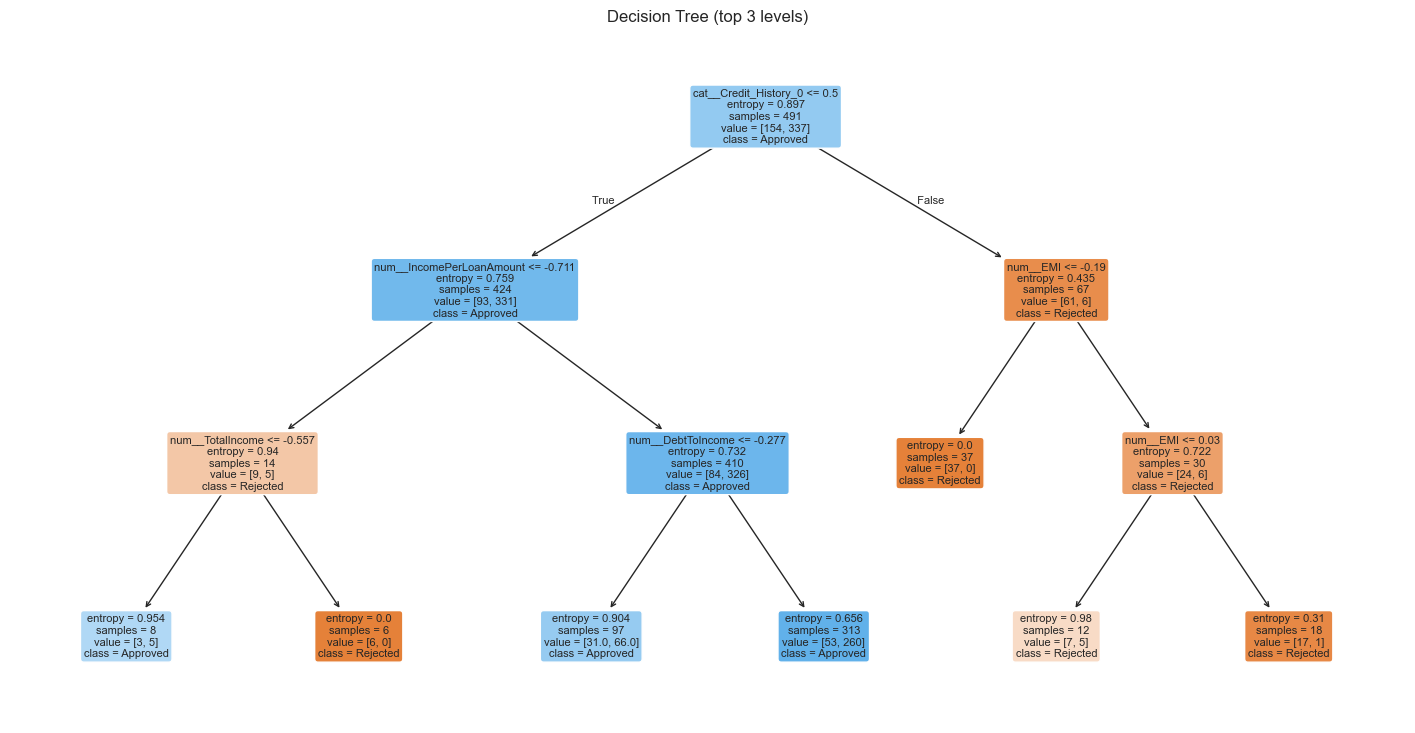

In [14]:
fitted_prep = dt_best.named_steps['prep']
feat_names = fitted_prep.get_feature_names_out().tolist()

fig, ax = plt.subplots(figsize=(18, 9))
plot_tree(dt_best.named_steps['clf'],
          feature_names=feat_names,
          class_names=['Rejected', 'Approved'],
          filled=True, rounded=True, fontsize=8, max_depth=3, ax=ax)
plt.title('Decision Tree (top 3 levels)')
plt.show()

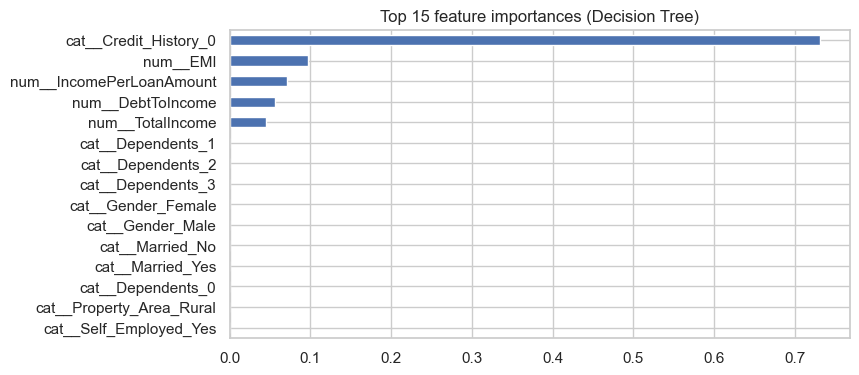

In [15]:
importances = pd.Series(
    dt_best.named_steps['clf'].feature_importances_, index=feat_names
).sort_values(ascending=False).head(15)
importances.plot(kind='barh', color='#4c72b0')
plt.gca().invert_yaxis()
plt.title('Top 15 feature importances (Decision Tree)')
plt.show()

As expected, **`Credit_History`** dominates. Income and loan-amount features fill in the secondary structure.

## 6. SVM

SVMs need scaled features (already in our pipeline). We tune `C`, `kernel`, and `gamma`.

In [16]:
svm_pipe = Pipeline([
    ('prep', preprocess),
    ('clf', SVC(probability=True, random_state=RANDOM_STATE)),
])

svm_grid = {
    'clf__C': [0.1, 1, 3, 10],
    'clf__kernel': ['linear', 'rbf'],
    'clf__gamma': ['scale', 'auto'],
    'clf__class_weight': [None, 'balanced'],
}

svm_search = GridSearchCV(svm_pipe, svm_grid, cv=5, scoring='f1', n_jobs=-1)
svm_search.fit(X_train, y_train)
print('Best SVM params:', svm_search.best_params_)
print(f'Best CV F1: {svm_search.best_score_:.4f}')
svm_best = svm_search.best_estimator_

svm_res = evaluate(svm_best, X_test, y_test, 'SVM')

Best SVM params: {'clf__C': 1, 'clf__class_weight': None, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Best CV F1: 0.8703

=== SVM ===
Accuracy : 0.8455
Precision: 0.8235
Recall   : 0.9882
F1       : 0.8984
ROC-AUC  : 0.8229
Confusion matrix:
[[20 18]
 [ 1 84]]
              precision    recall  f1-score   support

    Rejected       0.95      0.53      0.68        38
    Approved       0.82      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.76      0.79       123
weighted avg       0.86      0.85      0.83       123



## 7. Compare the two models

In [17]:
def metric_row(name, y_true, pred, proba):
    return {
        'model': name,
        'accuracy':  accuracy_score(y_true, pred),
        'precision': precision_score(y_true, pred),
        'recall':    recall_score(y_true, pred),
        'f1':        f1_score(y_true, pred),
        'roc_auc':   roc_auc_score(y_true, proba),
    }

summary = pd.DataFrame([
    metric_row('Decision Tree', y_test, dt_res['pred'], dt_res['proba']),
    metric_row('SVM',           y_test, svm_res['pred'], svm_res['proba']),
]).set_index('model').round(4)
summary

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Decision Tree,0.8618,0.8469,0.9765,0.9071,0.8525
SVM,0.8455,0.8235,0.9882,0.8984,0.8229


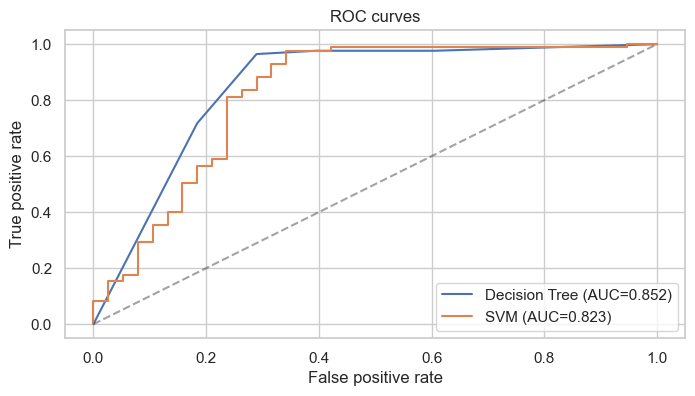

In [18]:
for name, res in [('Decision Tree', dt_res), ('SVM', svm_res)]:
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    auc = roc_auc_score(y_test, res['proba'])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False positive rate'); plt.ylabel('True positive rate')
plt.title('ROC curves'); plt.legend(); plt.show()

**Trade-off:** SVM often edges out the tree slightly on ROC-AUC, but the tree gives us **explainable rule paths** for every individual prediction — important for a loan-approval product where applicants deserve to know *why* they were rejected.

## 8. Persist the pipelines + the imputation values

In [19]:
os.makedirs('../models', exist_ok=True)
joblib.dump(dt_best,  '../models/dt_pipeline.joblib')
joblib.dump(svm_best, '../models/svm_pipeline.joblib')
joblib.dump(impute_values, '../models/impute_values.joblib')
print('Saved models/dt_pipeline.joblib, models/svm_pipeline.joblib, models/impute_values.joblib')

Saved models/dt_pipeline.joblib, models/svm_pipeline.joblib, models/impute_values.joblib


## 9. Next step — Streamlit app

Run from the project root:
```powershell
streamlit run app/streamlit_app.py
```
The app loads the saved pipelines and `impute_values`, applies the same `clean_and_engineer` function, and shows the prediction probability plus (for the Decision Tree) the rule path that led to the predicted leaf.